In [170]:
import pandas as pd
df = pd.read_csv("../../data/E Commerce Customer Insights and Churn Dataset.csv")

In [171]:
df.shape

(2000, 17)

El dataset cuenta con 2000 filas y 19 columnas (+2 calculadas la de recency_days y churn)

In [184]:
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"])

In [185]:
df.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender,total_price
0,ORD5000,CUST1000,39,PROD200,Canada,1/7/2021,2023-02-21,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female,391.05
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,2021-12-08,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female,512.16
2,ORD5002,CUST1002,26,PROD202,Pakistan,6/10/2023,2023-09-04,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female,1208.28
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2024-02-20,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male,338.64
4,ORD5004,CUST1004,50,PROD204,India,12/9/2020,2024-09-14,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male,438.62


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             2000 non-null   object        
 1   customer_id          2000 non-null   object        
 2   age                  2000 non-null   int64         
 3   product_id           2000 non-null   object        
 4   country              2000 non-null   object        
 5   signup_date          2000 non-null   object        
 6   last_purchase_date   2000 non-null   datetime64[ns]
 7   cancellations_count  2000 non-null   int64         
 8   subscription_status  2000 non-null   object        
 9   order_date           2000 non-null   object        
 10  unit_price           2000 non-null   float64       
 11  quantity             2000 non-null   int64         
 12  purchase_frequency   2000 non-null   int64         
 13  preferred_category   2000 non-nul

El dataset cuenta con 19 columnas:
Order_id: El id único de cada orden de un cliente
Customer_id: El id único de cada cliente
Age: La edad de cliente
Country: El país del cliente
Signup_date: Fecha de inscripción del cliente
Last_purchase_date: Fecha de última compra más reciente del cliente
Cancellations_count: Número de cancelaciones
Subscription_status: Estado de la inscripción
Order_date: Fecha de la orden del cliente
Unite_price: Precio unitario del producto pedido
Quantity: Cantidad de productos pedidos
Purchase_frequency: Frecuencia de pedidos realizados
Preferred_category: Categoría más comprada
Product_name: Nombre del producto
Category: Categoría del producto
Gender: Género del cliente

In [187]:
snapshot_date = df["last_purchase_date"].max()
print(snapshot_date)

2025-08-20 00:00:00


In [188]:
df["recency_days"] = (snapshot_date - df["last_purchase_date"]).dt.days

In [189]:
df["churn"] = df["recency_days"] > 60
df["churn"] = df["churn"].astype(int)

In [190]:
df["churn"].value_counts(normalize=True)*100

churn
1    94.9
0     5.1
Name: proportion, dtype: float64

In [191]:
df.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender,total_price,recency_days,churn
0,ORD5000,CUST1000,39,PROD200,Canada,1/7/2021,2023-02-21,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female,391.05,911,1
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,2021-12-08,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female,512.16,1351,1
2,ORD5002,CUST1002,26,PROD202,Pakistan,6/10/2023,2023-09-04,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female,1208.28,716,1
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2024-02-20,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male,338.64,547,1
4,ORD5004,CUST1004,50,PROD204,India,12/9/2020,2024-09-14,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male,438.62,340,1


## Distribución de churn

Se observa que el 94.9% de los clientes están clasificados como churn, mientras que solo el 5.1% no lo están.

Esto indica que el dataset se encuentra altamente desbalanceado.

Este comportamiento es consistente con la estructura del dataset, ya que la mayoría de los clientes presentan una única compra registrada, lo que incrementa su recencia y, bajo la definición adoptada, los clasifica como churn.

Esta situación puede afectar negativamente el entrenamiento del modelo, ya que este podría aprender a predecir mayoritariamente la clase dominante (churn).

In [192]:
df.groupby("churn")["purchase_frequency"].mean()

churn
0    23.225490
1    25.261855
Name: purchase_frequency, dtype: float64

Observación del comportamiento a nivel de frecuencia de compras de los cliente churn vs no churn.

In [193]:
import matplotlib.pyplot as plt
df["age"].hist()

plt.savefig("../reports/figures/age_hist.png")
plt.close()


<Axes: >

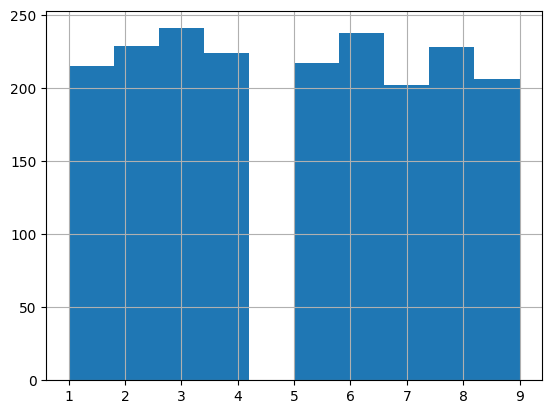

In [194]:
df["quantity"].hist()

In [195]:
import matplotlib.pyplot as plt
df["purchase_frequency"].hist(bins=20)
plt.savefig("../reports/figures/purchase_frequency_hist.png")
plt.close()

In [196]:
import matplotlib.pyplot as plt
df["recency_days"].hist()

plt.savefig("../reports/figures/recency_days_hist.png")
plt.close()

<Axes: xlabel='gender'>

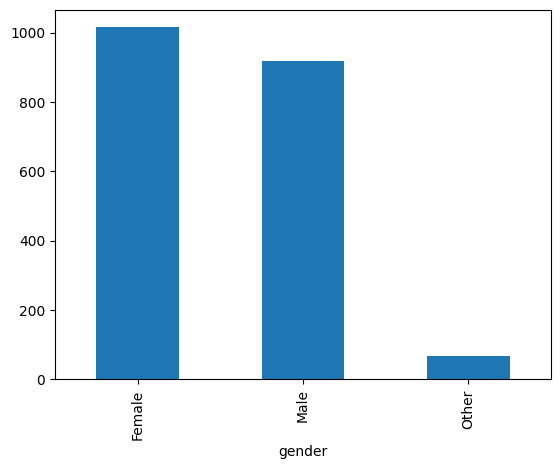

In [197]:
df["gender"].value_counts().plot(kind="bar")

In [198]:
import matplotlib.pyplot as plt
df["subscription_status"].value_counts().plot(kind="barh",ylabel="Estado de la inscripción",xlabel="Número de clientes")

plt.savefig("../reports/figures/subcription_status_bar.png")
plt.close()


In [199]:
df.isnull().sum()

order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
purchase_frequency     0
preferred_category     0
product_name           0
category               0
gender                 0
total_price            0
recency_days           0
churn                  0
dtype: int64

In [200]:
df["total_price"] = df["unit_price"]*df["quantity"]
df.groupby("churn")["total_price"].mean()

churn
0    1075.235196
1    1023.191075
Name: total_price, dtype: float64

El gasto promedio en la última compra de todos los clientes es ligeramente mayor de los clientes churn en comparación de los clientes no churn. Por ello, se determina que la variable total_price no es un factor determinante del churn.

In [201]:
df.groupby("churn")["cancellations_count"].mean()

churn
0    2.254902
1    2.451528
Name: cancellations_count, dtype: float64

In [202]:
pd.crosstab(df["churn"],df["country"],normalize="index")

country,Canada,Germany,India,Pakistan,UK,USA
churn,,,,,,
0,0.098039,0.215686,0.176471,0.205882,0.156863,0.147059
1,0.160695,0.178082,0.161222,0.163857,0.175975,0.160169


In [203]:
pd.crosstab(df["churn"],df["subscription_status"],normalize="index")

subscription_status,active,cancelled,paused
churn,,,
0,0.627451,0.235294,0.137255
1,0.600632,0.247102,0.152266


Se evaluó un dataset inicial con limitaciones y luego se utilizó uno más adecuado